In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df_california = pd.read_csv('housing.csv')

print("--- Primeras filas del dataset ---")
display(df_california.head())

print("\n--- Información del Dataset ---")
df_california.info()

print("\n--- Estadísticas Descriptivas Básicas---")
display(df_california.describe())

--- Primeras filas del dataset ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Estadísticas Descriptivas Básicas---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Limpieza y preprocesamiento base

In [36]:
print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_california.isnull().sum())


--- Conteo de Valores Nulos por Columna ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### Manejo de valores nulos

In [37]:
mediana_dormitorios = df_california['total_bedrooms'].median()

# Rellenamos (imputamos) los valores nulos con esa mediana
df_california.fillna({'total_bedrooms': mediana_dormitorios}, inplace=True)

# Verificamos que ya no haya nulos
print("Valores nulos después de la limpieza:")
print(df_california.isnull().sum())

Valores nulos después de la limpieza:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


### Análisis de la variable categórica

In [38]:
print("\n--- Categorías en 'ocean_proximity' ---")
display(df_california['ocean_proximity'].value_counts())


--- Categorías en 'ocean_proximity' ---


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Ingeniería de características (Feature Engineering)

In [39]:
# Crear variables lógicas por vivienda (household) en lugar de por cuadra (block)
df_california['rooms_per_household'] = df_california['total_rooms'] / df_california['households']
df_california['bedrooms_per_room'] = df_california['total_bedrooms'] / df_california['total_rooms']
df_california['population_per_household'] = df_california['population'] / df_california['households']

print("Nuevas características creadas exitosamente.")
display(df_california[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

Nuevas características creadas exitosamente.


,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


# Análisis Exploratorio Inicial (EDA) - (Distribuciones individuales)

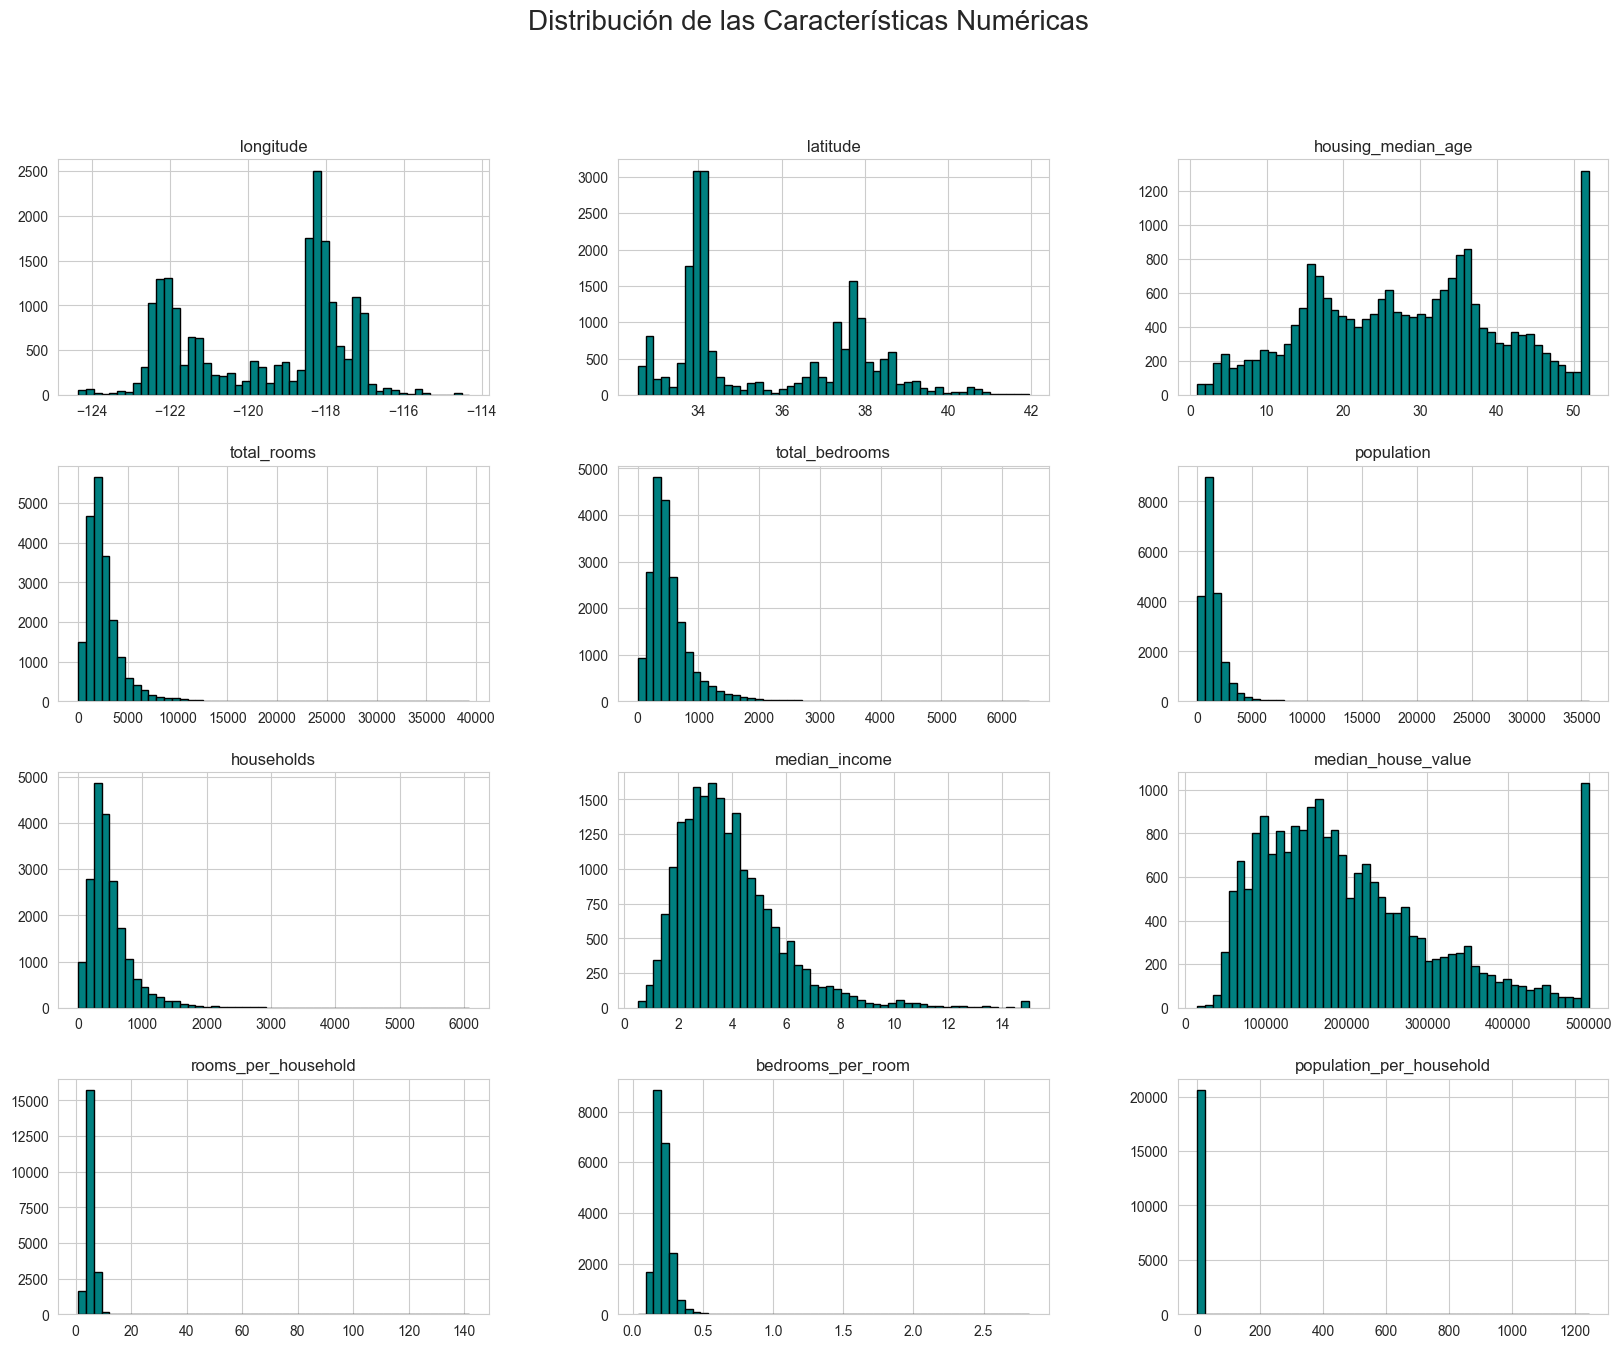

In [40]:
# Mapear la distribución de todas las variables numéricas
df_california.hist(bins=50, figsize=(20,15), color='teal', edgecolor='black')

plt.suptitle("Distribución de las Características Numéricas", fontsize=20)
plt.show()

### Conclusiones del Análisis de Distribuciones

Al observar los histogramas de las variables numéricas, podemos identificar tres fenómenos clave en los datos que debemos tener en cuenta para futuros modelos:

1. **Topes Artificiales (Capping):** La variable `median_house_value` muestra un pico atípico y masivo al final de su distribución (alrededor de los $500,000). Esto indica que los datos fueron limitados artificialmente durante su recolección; cualquier valor superior a ese umbral fue registrado con ese valor máximo. Ocurre un fenómeno idéntico en `housing_median_age` alrededor de los 50 años.
2. **Sesgo Positivo (Right-Skewness):** Variables como `median_income`, `total_rooms` y `population` tienen una "cola pesada" que se extiende hacia la derecha. Esto significa que la mayoría de los vecindarios tienen valores bajos o medios, pero existen unos pocos vecindarios con valores extremadamente altos (outliers) que estiran la distribución. 
3. **Escalas Diferentes:** Las variables están medidas en escalas muy distintas (ej. ingresos en decenas de miles vs. población en miles de personas). Si aplicamos algoritmos de Machine Learning más adelante, será crucial estandarizar o escalar estos datos.

# EDA AVANZADO (Segmentación y Filtrado)

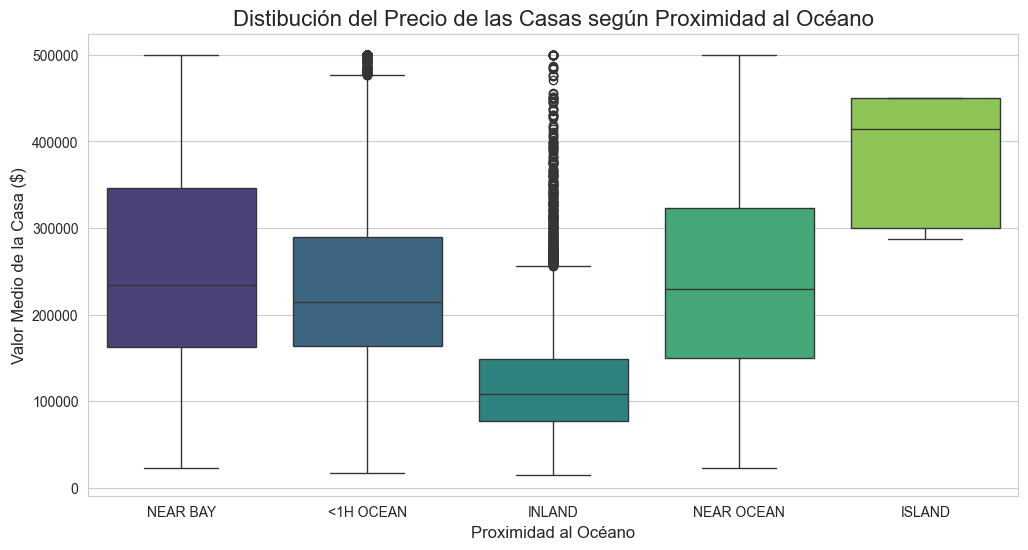

In [41]:
plt.figure(figsize=(12, 6))

# Creación del boxplot
# x: nuestra categoría de texto,
# y: el precio que queremos analizar
sns.boxplot(
    data=df_california,
    x='ocean_proximity',
    y='median_house_value',
    hue='ocean_proximity', # Asignamos colores por categoría
    palette='viridis',
    legend=False
)

plt.title('Distibución del Precio de las Casas según Proximidad al Océano', fontsize=16)
plt.xlabel('Proximidad al Océano', fontsize=12)
plt.ylabel('Valor Medio de la Casa ($)', fontsize=12)

plt.show()

### Conclusiones del gráfico - Boxplot
- La linea central de la caja es la mediana (el valor del medio). Esto indica visualmente que categoría es, en general, la más cara.
- El tamaño de la caja representa el 50% central de los datos. Las cajas estiradas significan que los precios en esa zona varían mucho. Si es muy aplastada significa que los precios son similares entre sí.
- Los puntos fuera de las líneas: Estos son los Outliers, (valores atípicos)
- Bigotes (Whiskers): La longitud de los bigotes indica la dispersión de los valores extremos. Por ejemplo, en 'NEAR BAY', el bigote inferior es muy largo, lo que sugiere que aunque la mayoría de las casas son caras, existe una cantidad considerable de propiedades con precios muy bajos en comparación con la mediana.

Aunque la categoría ISLAND muestra la mediana más alta, cabe destacar que solo cuenta con 5 registros, por lo que estos resultados no son estadísticamente significativos y podrían no representar la realidad de todas las propiedades

### One-Hot Encoding

In [42]:
# Convertimos la columna categórica en múltiples columnas de 1s y 0s
# Usamos dtype=int para que sean números enteros en lugar de booleanos (True/False)
df_california = pd.get_dummies(df_california, columns=['ocean_proximity'], dtype=int)

print("One-Hot Encoding aplicado. Columnas actuales relacionadas al océano")
# Mostramos solo las columnas nuevas que se generaron
columnas_oceano = [col for col in df_california.columns if 'ocean_proximity' in col]
display(df_california[columnas_oceano].head())

One-Hot Encoding aplicado. Columnas actuales relacionadas al océano


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0


# Relaciones y Correlaciones

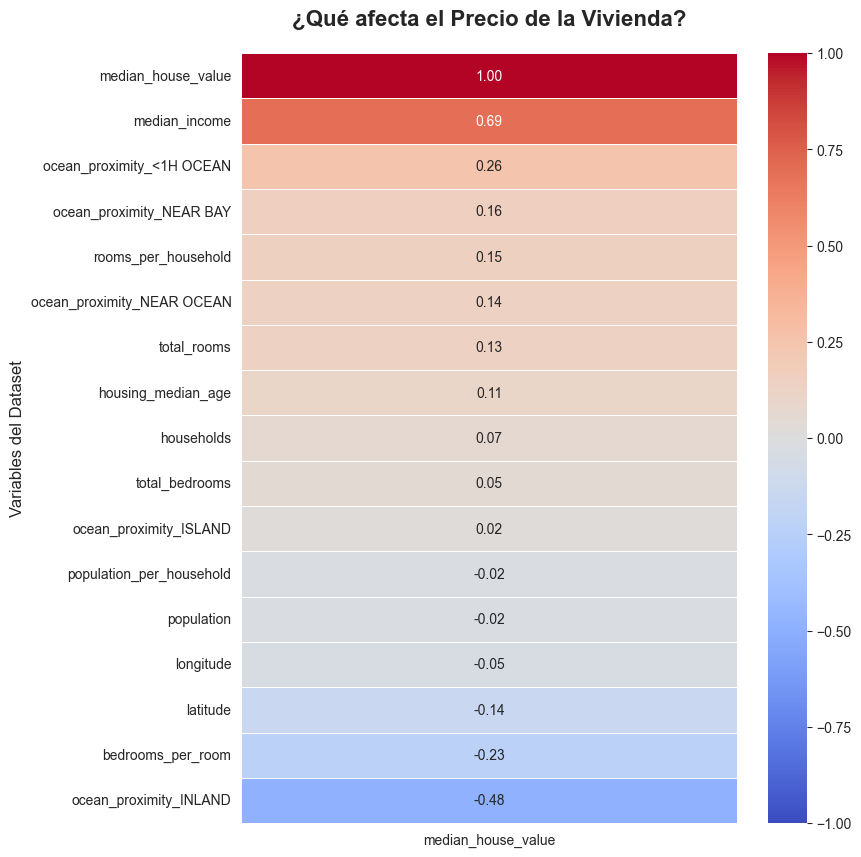

In [43]:
# PREPARACIÓN PARA EL HEATMAP
# Primero, seleccionamos solo las columnas numéricas (la correlación no funciona con textos)
columnas_numericas = df_california.select_dtypes(include=[np.number])

# 2. AISLAR Y ORDENAR: Calculamos la correlacion solo respecto al valor de la casa y ordenamos de mayor a menor
correlacion_precio = columnas_numericas.corr()[['median_house_value']].sort_values(by='median_house_value', ascending=False)

# 3. DIBUJAR EL HEATMAP UNIDIMENSIONAL
plt.figure(figsize=(8,10))
# Usamos vmin=-1 para que los colores extremos se mantengan consistentes
sns.heatmap(correlacion_precio, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('¿Qué afecta el Precio de la Vivienda?', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.show()

### PAIRPLOT (Matriz de dispersión)


Generando Pairplot...


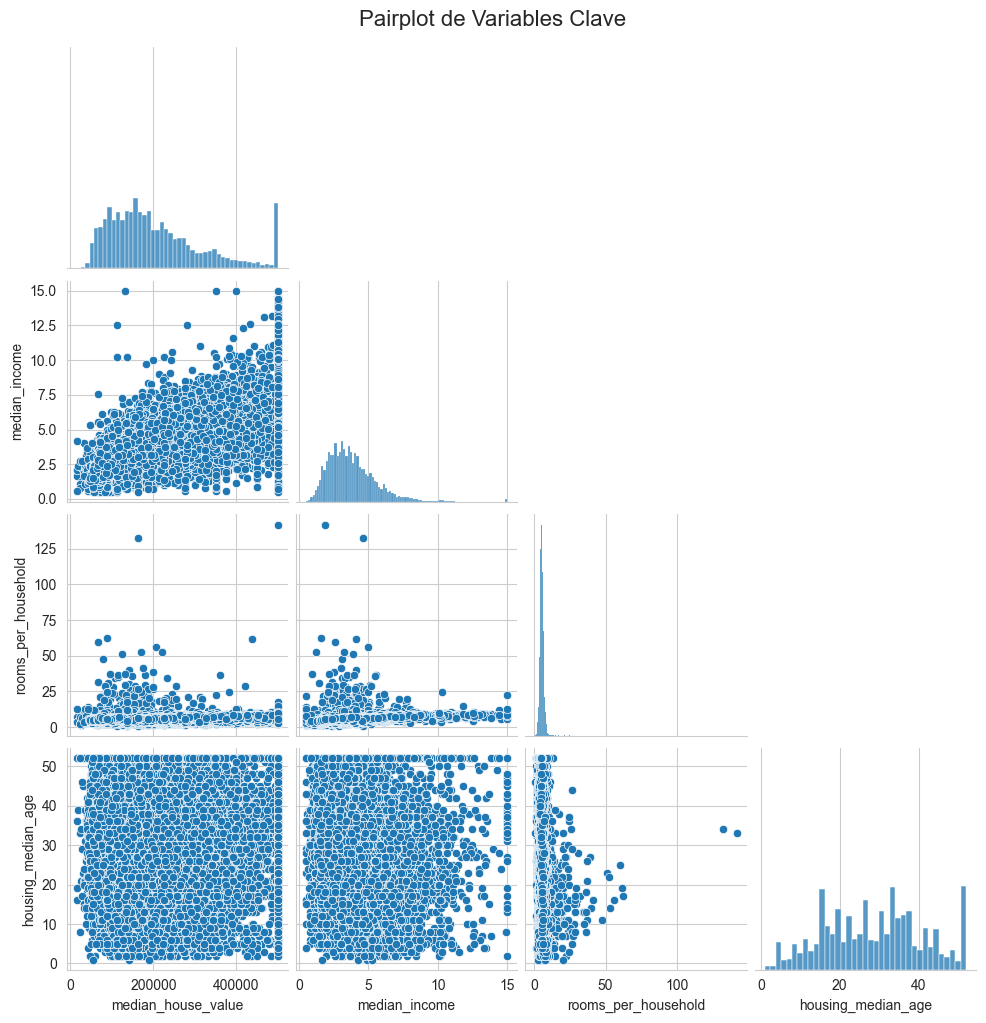

In [44]:
# Seleccionamos solo las variables que más nos interesan para no sobrecargar el gráfico
variables_clave = ['median_house_value', 'median_income', 'rooms_per_household', 'housing_median_age']

print("\nGenerando Pairplot...")
sns.pairplot(df_california[variables_clave], height=2.5, corner=True)
plt.suptitle('Pairplot de Variables Clave', y=1.02, fontsize=16)
plt.show()

### Conclusiones del Análisis de Correlación

Tras analizar el Mapa de Calor (Heatmap) extendido y el Pairplot, extraemos los siguientes hallazgos:

1. **El factor Principal: Los ingresos (Median Income):** Existe una correlación positiva fuerte (cercana a **0.69**) entre los ingresos medios de un vecindario y el valor medio de las casas. A medida que los ingresos suben, el precio de la propiedad se dispara. Esta es la relación lineal más clara de todo el dataset.
2. **Confirmación visual del Tope Artificial:** Al observar el gráfico de dispersión (scatter plot) entre `median_income` y `median_house_value` dentro del Pairplot, se hace muy evidente una línea horizontal sólida y antinatural exactamente en los **$500,000**. Esto reconfirma nuestra teoría anterior de que los datos fueron "topados" (capped) en ese valor límite durante la recolección del censo.
3. **Ingeniería de Características (La realidad por vivienda):** Al transformar los totales de bloque en métricas reales por hogar (como `rooms_per_household`), observamos cómo interactúan con el precio. Aunque son medidas más precisas que los totales crudos, su correlación sigue siendo relativamente baja. Esto nos da una pista contundente: el valor inmobiliario en California depende mucho más de "quién vive ahí" (ingresos) y "dónde está", que del tamaño o la antigüedad de la estructura misma.
4. **El "castigo" de vivir lejos de la costa:** Gracias a la transformación de las categorías de texto a números (One-Hot Encoding), ahora podemos medir matemáticamente el efecto de la ubicación. La nueva variable `ocean_proximity_INLAND` (tierra adentro) muestra una **fuerte correlación negativa** con el precio de la vivienda. Esto prueba matemáticamente que alejarse del mar reduce drásticamente el valor de la propiedad, consolidando la regla de oro inmobiliaria: *ubicación, ubicación, ubicación*.

### Visualización geográfica (Storytelling)

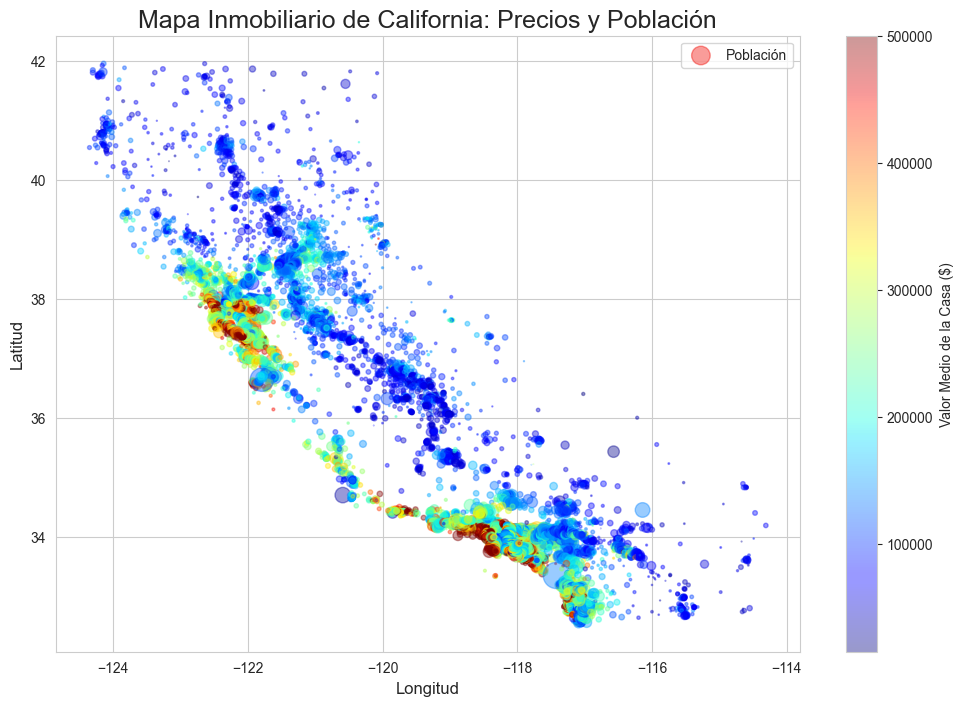

In [45]:
plt.figure(figsize=(12,8))

# Creamos el gráfico de dispersión (scatter plot)
# x = longitud
# y = latitud 
# Dibujarán la forma de la costa oeste

scatter = plt.scatter(
    x=df_california['longitude'],
    y=df_california['latitude'],
    alpha=0.4,    
    s=df_california['population'] / 100,    
    label='Población',
    c=df_california['median_house_value'],
    cmap='jet'
)

# Añadimos la barra de colores a la derecha para saber qué significa cada color
plt.colorbar(scatter, label='Valor Medio de la Casa ($)')

plt.title('Mapa Inmobiliario de California: Precios y Población', fontsize=18)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()

plt.show()

### Conclusión: El Enigma de los Precios en California

Tras realizar la limpieza, el Análisis Exploratorio y la Visualización Geográfica, podemos responder al desafío inicial: **¿Qué hace que las casas sean tan caras en California?**

La respuesta se reduce a una combinación de dos factores principales:

1. **Ubicación, (La costa manda):** El mapa de calor geográfico demuestra visualmente que los precios más altos (en rojo) se concentran fuertemente en la costa del Océano Pacífico, específicamente formando clústeres alrededor de los grandes polos urbanos (Área de la Bahía y Los Ángeles). A medida que nos alejamos del océano hacia el interior (Inland), los precios caen drásticamente.
2. **Poder Adquisitivo (El factor Ingresos):** Como descubrimos en nuestro análisis de correlación (0.69), la cercanía al mar no lo es todo; el precio de las casas está íntimamente ligado a los ingresos medios de los residentes del vecindario. La demanda por vivir en estas zonas costeras privilegiadas atrae a personas con altos ingresos, lo que a su vez dispara el valor del mercado inmobiliario local.

*Nota técnica: Nuestro modelo futuro deberá tener cuidado con los topes artificiales (capping) en los $500,000 dólares detectados durante el EDA, ya que podrían sesgar las predicciones.*